In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd 

In [3]:
#data load 
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
#perform EDA 
import matplotlib.pyplot as plt 
import seaborn as sns

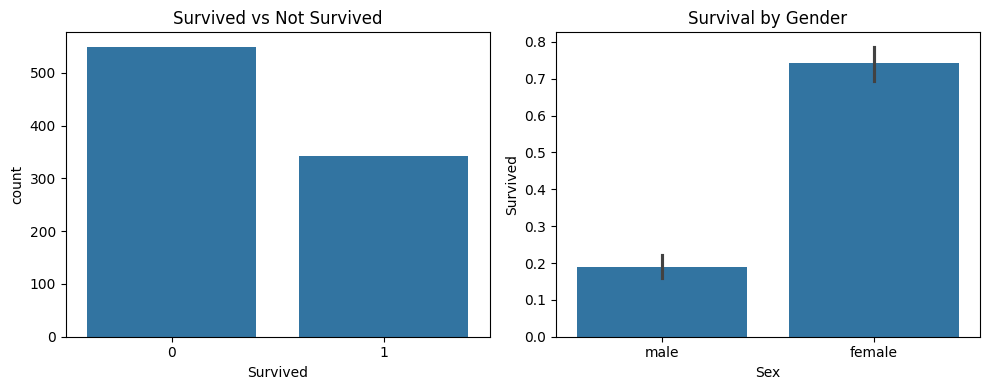

In [7]:
plt.figure(figsize=(10,4)) #width,height

#survival count 
plt.subplot(1,2,1)  #row,column,index
sns.countplot(x='Survived',data=df)  #for comparison
plt.title('Survived vs Not Survived')

# Gender vs Survival
plt.subplot(1,2,2)
sns.barplot(x='Sex',y='Survived',data=df)
plt.title('Survival by Gender')

plt.tight_layout() #auto adjust ,ensures no overlap
plt.show()

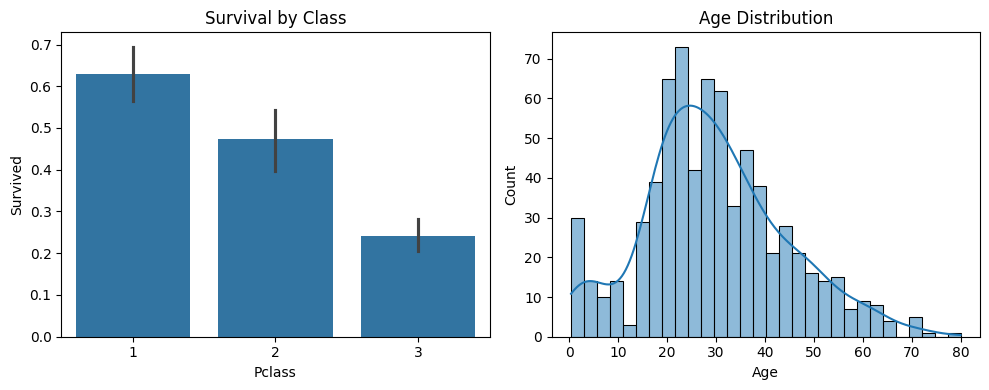

In [8]:
plt.figure(figsize=(10,4))

# Class vs Survival
plt.subplot(1,2,1)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival by Class')

# Age distribution
plt.subplot(1,2,2)
sns.histplot(df['Age'].dropna(), bins=30, kde=True) #data spread (if we made coutplot difficult to rread cuz 80 bars would formed)
plt.title('Age Distribution')

plt.tight_layout() #auto adjust
plt.show()

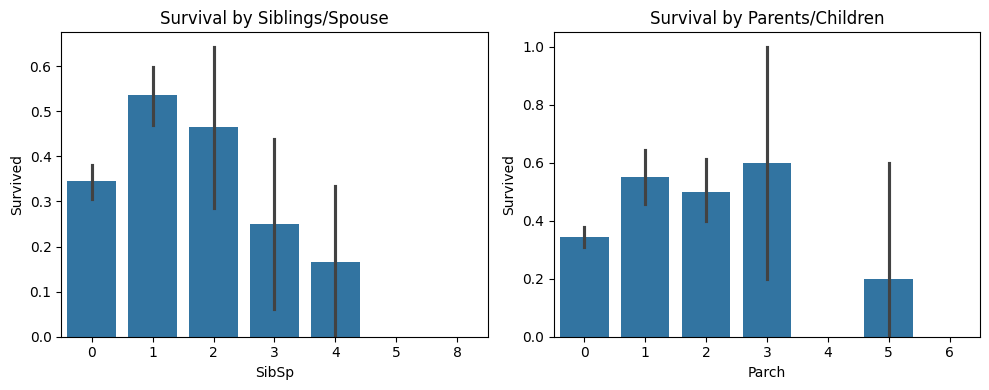

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(x='SibSp', y='Survived', data=df)
plt.title('Survival by Siblings/Spouse')

plt.subplot(1,2,2)
sns.barplot(x='Parch', y='Survived', data=df)
plt.title('Survival by Parents/Children')

plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
numeric_cols=['Age', 'Fare', 'SibSp', 'Parch']
categorical_cols=['Sex', 'Embarked', 'Pclass']

X= df[numeric_cols + categorical_cols]
y=df['Survived']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
X.shape

(891, 7)

In [15]:
X_train.shape

(712, 7)

In [16]:

X_test.shape

(179, 7)

In [17]:
891-712

179

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [19]:
# Numeric columns ke liye
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical columns ke liye
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Dono combine karo
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print('Preprocessor ready!')

Preprocessor ready!


In [20]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    results[name] = {
        'CV Mean': round(cv_scores.mean(), 3),
        'Test Accuracy': round(test_acc, 3)
    }
    print(f'{name}: CV={cv_scores.mean():.3f} | Test={test_acc:.3f}')

print('\n=== COMPARISON TABLE ===')
print(pd.DataFrame(results).T)

Logistic Regression: CV=0.793 | Test=0.799
Random Forest: CV=0.791 | Test=0.821
XGBoost: CV=0.796 | Test=0.788

=== COMPARISON TABLE ===
                     CV Mean  Test Accuracy
Logistic Regression    0.793          0.799
Random Forest          0.791          0.821
XGBoost                0.796          0.788


In [21]:
# Best model final train
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

best_pipeline.fit(X_train, y_train)
predictions = best_pipeline.predict(X_test)

print(f'Final Accuracy: {accuracy_score(y_test, predictions):.2%}')
print('\nClassification Report:')
print(classification_report(y_test, predictions))

Final Accuracy: 82.12%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



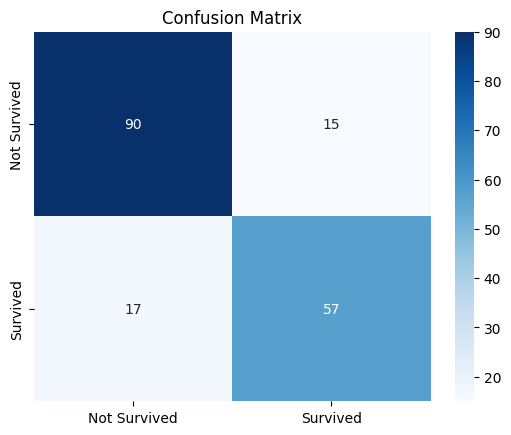

In [22]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.show()

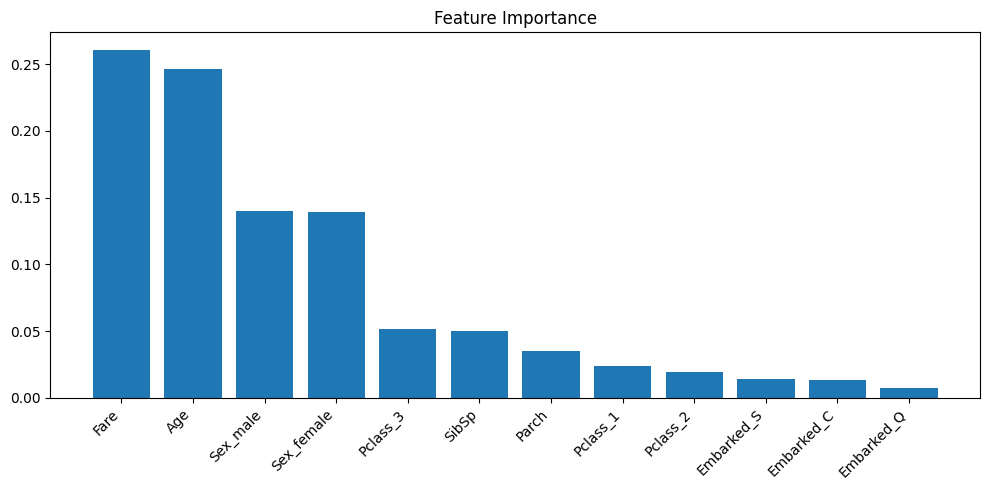

In [24]:
import numpy as np

feature_names = (numeric_cols +
    list(best_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)))

importances = best_pipeline.named_steps['model'].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [25]:
import joblib
joblib.dump(best_pipeline, 'titanic_pipeline.pkl')
print('Model saved!')

Model saved!


# Titanic Survival Prediction Pipeline

## Problem
Predict whether a passenger survived the Titanic disaster.

## Approach
- EDA: Explored survival patterns by gender, class, age
- Built sklearn Pipeline: preprocessing + model
- Compared 3 models: Logistic Regression, Random Forest, XGBoost
- Best Model: Random Forest (82.12% accuracy)

## Key Findings
- Fare and Age were most important features
- Females survived much more than males (74% vs 19%)
- 1st class passengers survived most (63%)

## Results
| Model | CV Score | Test Accuracy |
|-------|----------|---------------|
| Logistic Regression | 0.793 | 0.799 |
| Random Forest | 0.791 | 0.821 |
| XGBoost | 0.796 | 0.788 |